<a href="https://colab.research.google.com/github/sittidetw/DADS6003/blob/main/hw4_classification/DADS6003_HW4_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DADS6003 Homework 4: Credit Score Classification

**Objective**: Classify customer credit scores into three categories — **Standard**, **Good**, and **Poor** — using Logistic Regression and Naive Bayes models.

**Evaluation**: F1 Score (Weighted & Macro)

---

## 1. Setup & Data Loading

In [ ]:
!pip install optuna shap -q

In [ ]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("✅ All libraries imported successfully!")


/var/folders/b8/98n8j8hj7z1_rk8nsytvc6km0000gn/T/ipykernel_9560/2979953753.py:2: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)
/Users/sittidet.w/Documents/NIDA/2568-2/DADS6003/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!


In [ ]:
import os

# Auto-detect environment (Colab vs Local)
if os.path.exists('/content'):
    # Running on Google Colab
    !git clone https://github.com/sittidetw/DADS6003.git 2>/dev/null || echo 'Repository already cloned.'
    file_path_train = '/content/DADS6003/hw4_classification/raw_data/train.csv'
    file_path_test = '/content/DADS6003/hw4_classification/raw_data/test.csv'
else:
    # Running locally
    file_path_train = 'raw_data/train.csv'
    file_path_test = 'raw_data/test.csv'

try:
    df_train = pd.read_csv(file_path_train)
    print(f'✅ Train data loaded: {df_train.shape}')
except FileNotFoundError:
    print(f'❌ File not found at {file_path_train}')

try:
    df_test_raw = pd.read_csv(file_path_test)
    print(f'✅ Test data loaded:  {df_test_raw.shape}')
except FileNotFoundError:
    print(f'❌ File not found at {file_path_test}')

print()
print('=== Train Credit_Score Distribution ===')
print(df_train['Credit_Score'].value_counts())
print()
print('=== Train Missing Values ===')
missing = df_train.isnull().sum()
print(missing[missing > 0])
print()
display(df_train.head(3))


✅ Train data loaded: (80000, 28)
✅ Test data loaded:  (20000, 28)

=== Train Credit_Score Distribution ===
Credit_Score
Standard    42537
Poor        23141
Good        14322
Name: count, dtype: int64

=== Train Missing Values ===
Name                        8008
Monthly_Inhand_Salary      11962
Type_of_Loan                9213
Num_of_Delayed_Payment      5628
Num_Credit_Inquiries        1579
Credit_History_Age          7223
Amount_invested_monthly     3530
Monthly_Balance              941
dtype: int64



,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1d1af,CUS_0x3539,February,an Arakalid,30,995-31-4669,Manager,43391.96,3688.996667,1,...,Good,1468.28,29.112468,23 Years and 8 Months,No,0.000000,53.969385063055675,High_spent_Large_value_payments,554.9302816036111,Good
1,0x1ebd6,CUS_0x8716,January,Matthewz,18,185-99-8068,Scientist,14351.21,NaN,8,...,Bad,4766.87,39.849732,NaN,Yes,61.098718,118.08021357217683,Low_spent_Small_value_payments,238.3144849566528,Poor
2,0x8a66,CUS_0x21dc,January,Tom Miless,41,241-53-8475,Developer,130125.04,10871.753333,5,...,Good,1195.05,21.542892,15 Years and 11 Months,No,204.285650,1255.8993022448951,Low_spent_Small_value_payments,NaN,Good


---

## 2. Data Preprocessing

We build a robust `data_cleaning()` function that handles:
- Cleaning messy numeric strings (e.g., `"25_"` → `25.0`)
- Converting `Credit_History_Age` from text to total months
- Encoding categorical variables: `Credit_Mix` (ordinal), `Payment_of_Min_Amount` (one-hot)
- Handling missing values: group-by-customer imputation → global median fallback
- Outlier capping using IQR bounds
- Dropping non-predictive columns (Name, SSN, etc.)

### Helper Functions

In [ ]:
def clean_numeric_string(val):
    """Clean messy numeric strings by keeping only digits, dots, and minus signs."""
    if pd.isna(val):
        return np.nan
    val = str(val)
    cleaned_val = re.sub(r'[^\d.-]', '', val)
    try:
        return float(cleaned_val) if cleaned_val else np.nan
    except ValueError:
        return np.nan


def convert_age_to_months(val):
    """Convert 'XX Years and YY Months' string to total months."""
    if pd.isna(val):
        return np.nan
    val = str(val)
    years = re.search(r'(\d+) Years', val)
    months = re.search(r'(\d+) Months', val)
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    return (y * 12) + m

print("✅ Helper functions defined.")


✅ Helper functions defined.


### Data Cleaning Function

In [ ]:
def data_cleaning(df_temp, is_test=False, global_medians=None, lower_bounds=None, upper_bounds=None):
    """
    Clean and preprocess the credit score dataset.

    Parameters:
    -----------
    df_temp        : pd.DataFrame - Raw input dataframe
    is_test        : bool - If True, uses pre-computed statistics from training data
    global_medians : pd.Series - Median values for imputation (from training data)
    lower_bounds   : pd.Series - IQR lower bounds for outlier capping (from training data)
    upper_bounds   : pd.Series - IQR upper bounds for outlier capping (from training data)

    Returns:
    --------
    If is_test=False: (cleaned_df, global_medians, lower_bounds, upper_bounds)
    If is_test=True:  cleaned_df
    """
    df = df_temp.copy()

    # ---- 1. Drop non-useful columns ----
    columns_to_drop = ['Month', 'Name', 'SSN', 'Type_of_Loan', 'Occupation', 'Payment_Behaviour']
    df.drop(columns=[c for c in columns_to_drop if c in df.columns], inplace=True)
    df.set_index('ID', inplace=True)

    # ---- 2. Clean messy numeric strings ----
    messy_num_cols = [
        'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
        'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
        'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
        'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
        'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
    ]
    for col in messy_num_cols:
        if col in df.columns:
            df[col] = df[col].apply(clean_numeric_string)

    # ---- 3. Convert Credit_History_Age to total months ----
    if 'Credit_History_Age' in df.columns:
        df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_age_to_months)

    # ---- 4. Encode Credit_Mix (ordinal: Bad=0, Standard=1, Good=2) ----
    if 'Credit_Mix' in df.columns:
        credit_mix_map = {'Good': 2, 'Standard': 1, 'Bad': 0}
        df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map)

    # ---- 5. Identify numeric columns (exclude target) ----
    target_col = 'Credit_Score'
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # ---- 6. Missing value imputation ----
    # Step A: Group-by-customer mean imputation
    if 'Customer_ID' in df.columns:
        group_means = df.groupby('Customer_ID')[numeric_cols].transform('mean')
        df[numeric_cols] = df[numeric_cols].fillna(group_means)

    # Step B: Global median fallback
    if global_medians is None:
        global_medians = df[numeric_cols].median()
    df[numeric_cols] = df[numeric_cols].fillna(global_medians)

    # ---- 7. Outlier capping using IQR ----
    if lower_bounds is None or upper_bounds is None:
        Q1 = df[numeric_cols].quantile(0.25)
        Q3 = df[numeric_cols].quantile(0.75)
        IQR = Q3 - Q1
        lower_bounds = Q1 - 1.5 * IQR
        upper_bounds = Q3 + 1.5 * IQR

    for col in numeric_cols:
        if col in lower_bounds.index:
            df[col] = df[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])

    # ---- 8. Abnormal Values ----
    cols_to_fix = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit','Monthly_Balance', 'Delay_from_due_date']
    for col in cols_to_fix:
        df.loc[df[col] < 0, col] = global_medians.loc[col]

    int_cols = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Num_of_Delayed_Payment']
    df[int_cols] = df[int_cols].round(0).astype(int)

    df = df[(df['Age'] > 0) & (df['Age'] < 100)]

    # ---- 9. One-Hot Encoding for Payment_of_Min_Amount ----
    if 'Payment_of_Min_Amount' in df.columns:
        df = pd.get_dummies(df, columns=['Payment_of_Min_Amount'], drop_first=True)

    # ---- 10. Drop Customer_ID ----
    if 'Customer_ID' in df.columns:
        df.drop(columns=['Customer_ID'], inplace=True)

    # ---- 11. Place Credit_Score as last column (if present) ----
    if target_col in df.columns:
        cols = [col for col in df.columns if col != target_col] + [target_col]
        df = df[cols]

    if is_test:
        return df
    else:
        return df, global_medians, lower_bounds, upper_bounds

print("✅ data_cleaning() function defined.")


✅ data_cleaning() function defined.


### Apply Cleaning to Training Data

In [ ]:
df_cleaned, global_medians, lower_bounds, upper_bounds = data_cleaning(df_train)

print(f"✅ Cleaned train shape: {df_cleaned.shape}")
print()
display(df_cleaned.info())
print()
display(df_cleaned.describe().T)


✅ Cleaned train shape: (80000, 21)

<class 'pandas.DataFrame'>
Index: 80000 entries, 0x1d1af to 0x2468
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        80000 non-null  float64
 1   Annual_Income              80000 non-null  float64
 2   Monthly_Inhand_Salary      80000 non-null  float64
 3   Num_Bank_Accounts          80000 non-null  int64  
 4   Num_Credit_Card            80000 non-null  int64  
 5   Interest_Rate              80000 non-null  float64
 6   Num_of_Loan                80000 non-null  int64  
 7   Delay_from_due_date        80000 non-null  float64
 8   Num_of_Delayed_Payment     80000 non-null  int64  
 9   Changed_Credit_Limit       80000 non-null  float64
 10  Num_Credit_Inquiries       80000 non-null  float64
 11  Credit_Mix                 80000 non-null  float64
 12  Outstanding_Debt           80000 non-null  float64
 13  Credit_Utilization_

None

,count,mean,std,min,25%,50%,75%,max
Age,80000.0,33.999725,11.678758,14.000000,25.000000,33.000000,42.000000,69.000000
Annual_Income,80000.0,51329.129015,38854.379821,7005.930000,19433.067500,37550.740000,72896.120000,153090.698750
Monthly_Inhand_Salary,80000.0,4174.007206,3118.682399,303.645417,1623.664167,3086.756667,5964.883333,12476.712083
Num_Bank_Accounts,80000.0,5.462987,2.715064,0.000000,3.000000,6.000000,7.000000,13.000000
Num_Credit_Card,80000.0,5.677450,2.256136,0.000000,4.000000,5.000000,7.000000,12.000000
Interest_Rate,80000.0,14.980037,9.252711,1.000000,8.000000,13.000000,20.000000,38.000000
Num_of_Loan,80000.0,3.545237,2.453926,0.000000,2.000000,3.000000,5.000000,11.000000
Delay_from_due_date,80000.0,21.012313,14.336491,0.000000,10.000000,18.000000,28.000000,55.000000
Num_of_Delayed_Payment,80000.0,13.617925,6.426503,0.000000,9.000000,14.000000,18.000000,32.000000
Changed_Credit_Limit,80000.0,10.559792,6.552482,0.000000,5.640000,9.400000,14.810000,29.030000


---

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

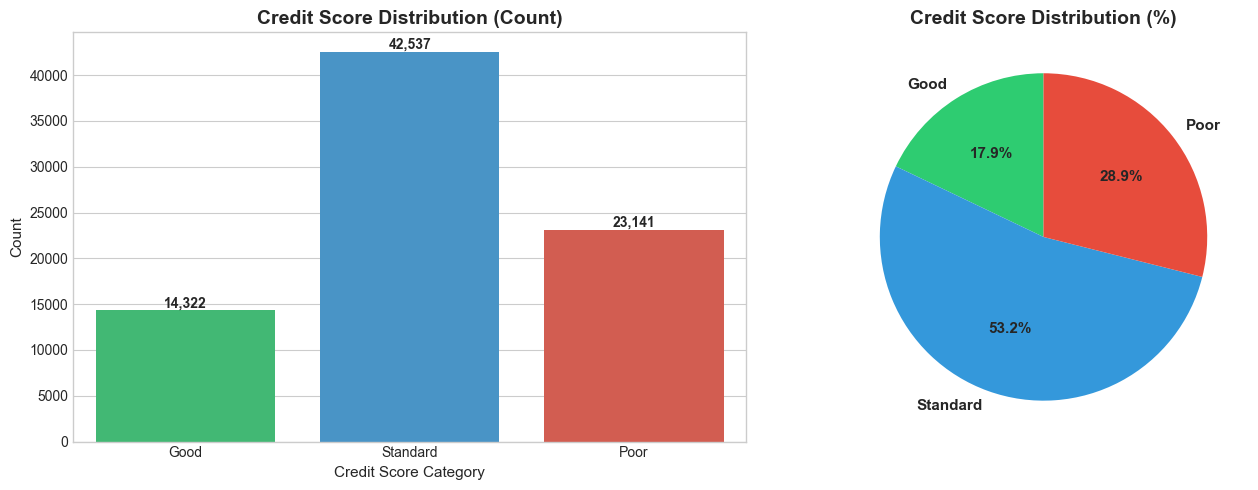

Class proportions:
Credit_Score
Standard    53.17
Poor        28.93
Good        17.90
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
order = ['Good', 'Standard', 'Poor']
colors_target = ['#2ecc71', '#3498db', '#e74c3c']
ax = axes[0]
sns.countplot(data=df_cleaned, x='Credit_Score', order=order, palette=colors_target, ax=ax)
ax.set_title('Credit Score Distribution (Count)', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score Category', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax = axes[1]
counts = df_cleaned['Credit_Score'].value_counts().reindex(order)
ax.pie(counts, labels=order, colors=colors_target, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Credit Score Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Class proportions:")
print(df_cleaned['Credit_Score'].value_counts(normalize=True).round(4) * 100)


### 3.2 Univariate Analysis — Numerical Features

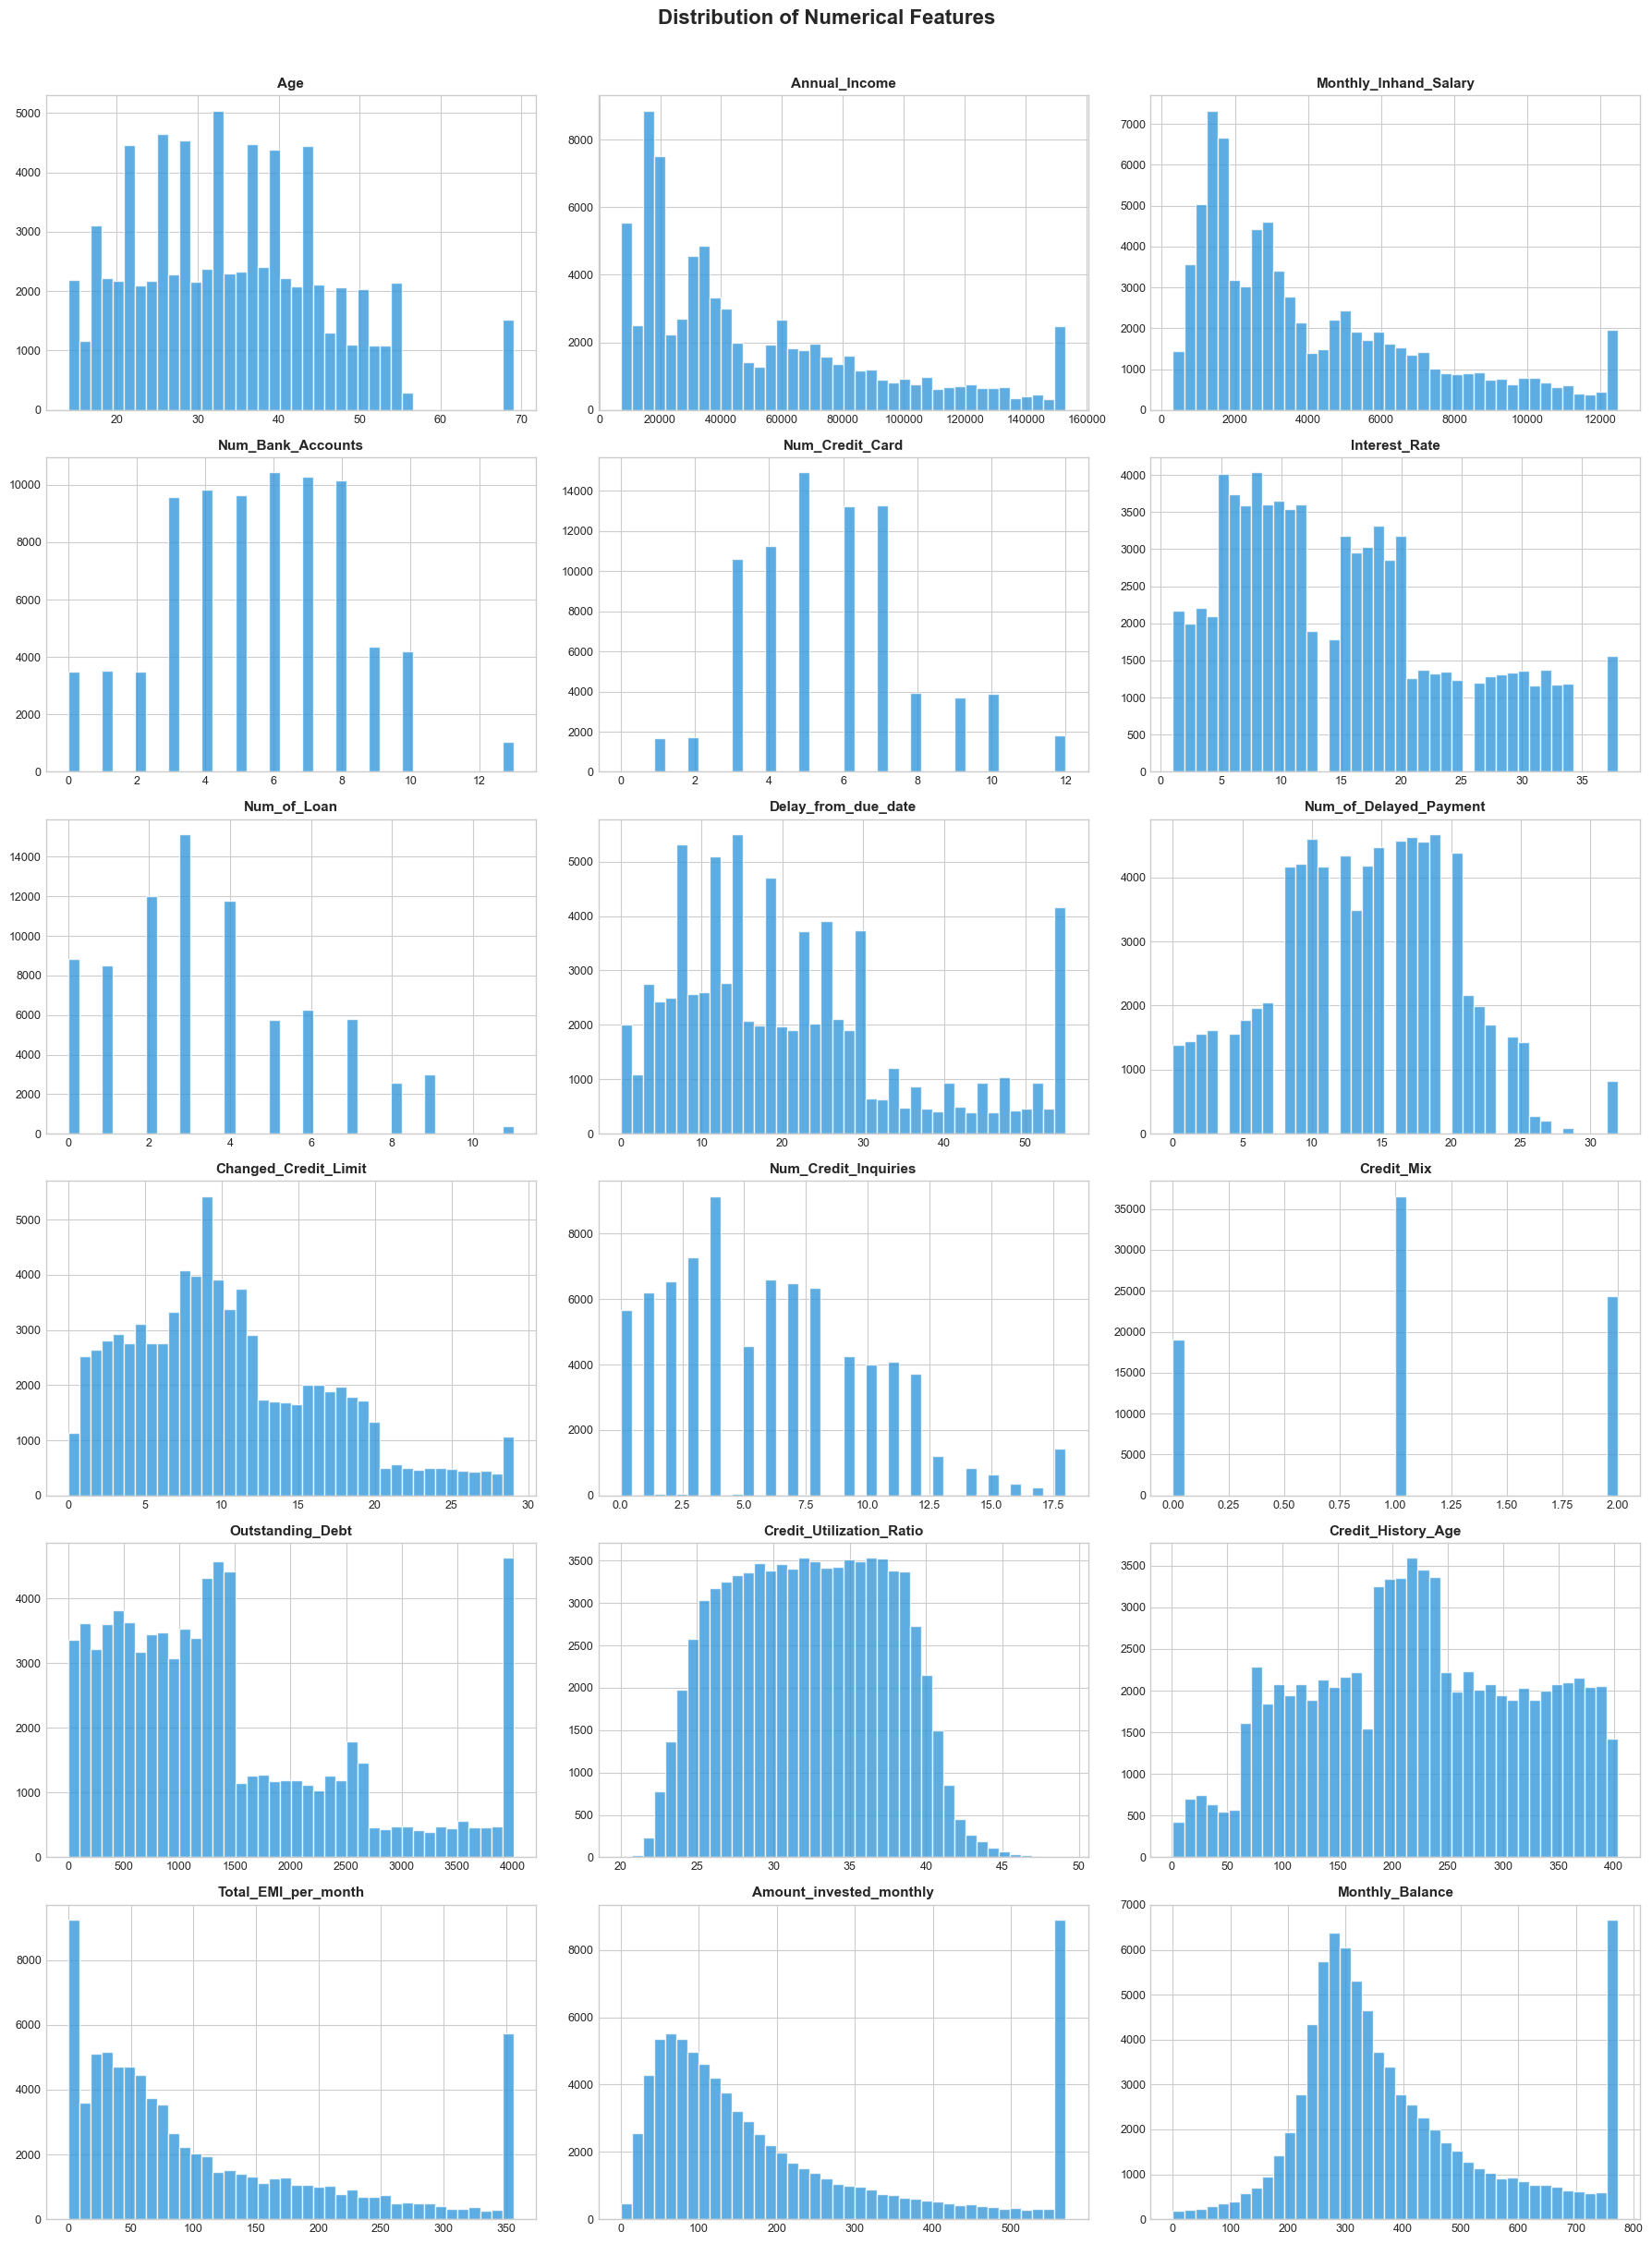

In [ ]:
numeric_features = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df_cleaned[col].hist(bins=40, ax=axes[i], color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=9)

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.3 Bivariate Analysis — Key Features vs Credit Score

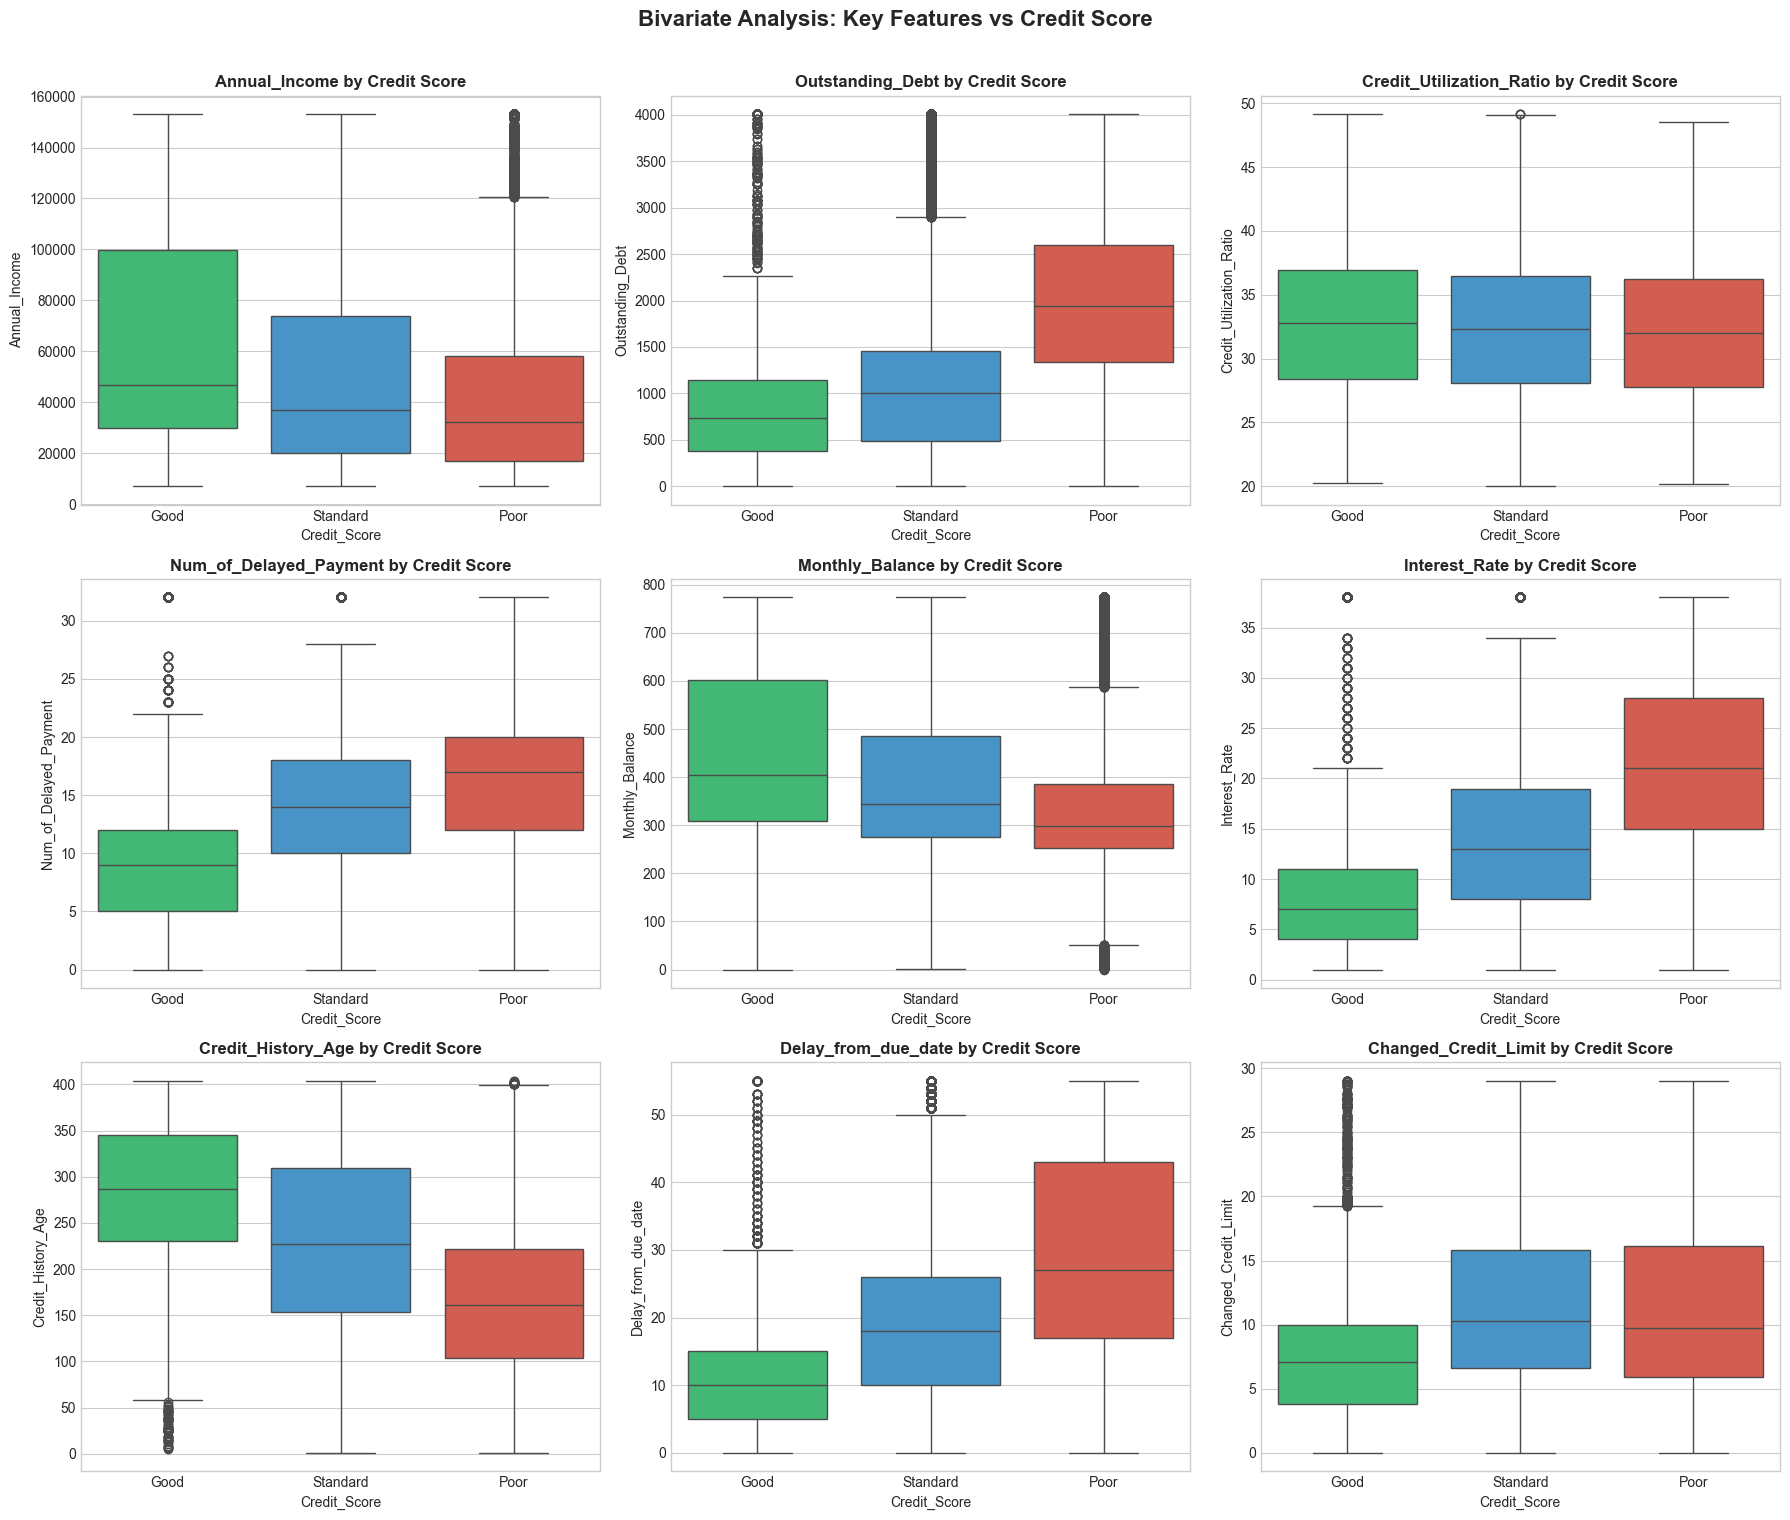

In [ ]:
key_features = ['Annual_Income', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
                'Num_of_Delayed_Payment', 'Monthly_Balance', 'Interest_Rate',
                'Credit_History_Age', 'Delay_from_due_date', 'Changed_Credit_Limit']

n_feat = len(key_features)
n_cols_bv = 3
n_rows_bv = (n_feat + n_cols_bv - 1) // n_cols_bv

fig, axes = plt.subplots(n_rows_bv, n_cols_bv, figsize=(18, 5 * n_rows_bv))
axes = axes.flatten()
order_bv = ['Good', 'Standard', 'Poor']
colors_bv = ['#2ecc71', '#3498db', '#e74c3c']

for i, col in enumerate(key_features):
    sns.boxplot(data=df_cleaned, x='Credit_Score', y=col, order=order_bv,
                palette=colors_bv, ax=axes[i])
    axes[i].set_title(f'{col} by Credit Score', fontsize=12, fontweight='bold')

for j in range(n_feat, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis: Key Features vs Credit Score',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap

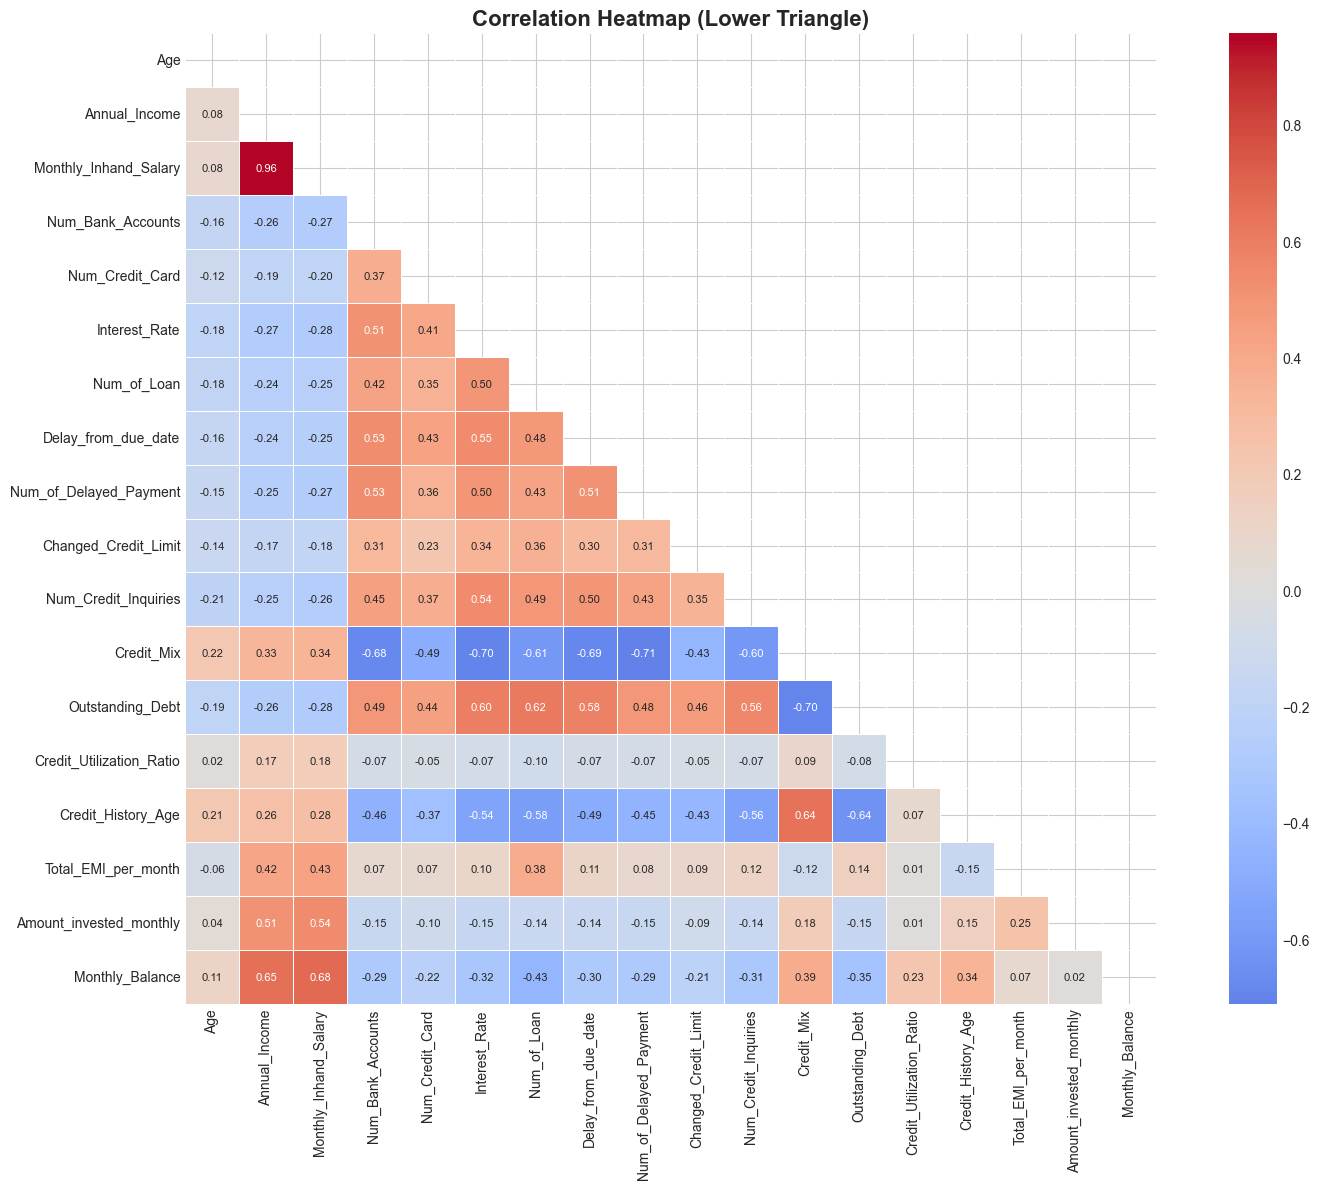

⚠️ Highly correlated pairs (|r| > 0.7):
   Annual_Income ↔ Monthly_Inhand_Salary: 0.957
   Num_of_Delayed_Payment ↔ Credit_Mix: -0.711


In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = df_cleaned.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap (Lower Triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (|r| > 0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              round(corr_matrix.iloc[i, j], 3)))

if high_corr:
    print("⚠️ Highly correlated pairs (|r| > 0.7):")
    for c1, c2, r in high_corr:
        print(f"   {c1} ↔ {c2}: {r}")
else:
    print("✅ No highly correlated pairs found (|r| > 0.7).")


### 3.5 EDA Summary

**Key Findings:**

1. **Class Imbalance**: Standard (~53%) dominates, followed by Poor (~29%), then Good (~18%). We address this using `class_weight='balanced'` in Logistic Regression and stratified splitting.
2. **Income & Monthly Balance**: Customers with **Good** credit tend to have significantly higher annual income and monthly balance.
3. **Delayed Payments**: Higher number of delayed payments and longer delay from due date strongly correlate with **Poor** credit scores.
4. **Interest Rate**: Poor-credit customers tend to carry higher interest rates.
5. **Outstanding Debt**: Higher outstanding debt is associated with poorer credit scores.
6. **Credit History Age**: Longer credit history is associated with better credit scores.
7. **Credit Utilization**: Relatively similar distributions across categories — may have limited discriminative power alone.

---

## 4. Train-Test Split

- Separate features (X) from target (y)
- Stratified split (80/20) to preserve class proportions
- Apply `StandardScaler` fitted on training data

In [ ]:
# Separate features and target
X = df_cleaned.drop(columns=['Credit_Score'])
y = df_cleaned['Credit_Score']

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", label_encoder.classes_)
print("Encoded mapping:", dict(zip(label_encoder.classes_,
                                    label_encoder.transform(label_encoder.classes_))))

# Stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

print(f"\nTrain set: {X_train.shape}")
print(f"Val set:   {X_val.shape}")
print(f"\nTrain class distribution: {dict(zip(label_encoder.classes_, np.bincount(y_train)))}")
print(f"Val class distribution:   {dict(zip(label_encoder.classes_, np.bincount(y_val)))}")


Target classes: ['Good' 'Poor' 'Standard']
Encoded mapping: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}

Train set: (64000, 20)
Val set:   (16000, 20)

Train class distribution: {'Good': np.int64(11457), 'Poor': np.int64(18513), 'Standard': np.int64(34030)}
Val class distribution:   {'Good': np.int64(2865), 'Poor': np.int64(4628), 'Standard': np.int64(8507)}


In [ ]:
# Feature Scaling — fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Store feature names for later use
feature_names = X_train.columns.tolist()

print(f"✅ Features scaled. {len(feature_names)} features:")
print(feature_names)


✅ Features scaled. 20 features:
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Payment_of_Min_Amount_No', 'Payment_of_Min_Amount_Yes']


In [ ]:
# ── Class Imbalance: SMOTE → TomekLinks ──────────────────────────────────────
# Applied AFTER scaling and ONLY on training data → no data leakage to val/test
#
# Step 1 — SMOTE: oversample minority classes up to Standard
# Step 2 — TomekLinks: less aggressive undersampling, only removes overlapping pairs
#          → keeps the "body" of the classes intact compared to ENN

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from collections import Counter

print("Class distribution BEFORE SMOTE+TomekLinks:")
before = Counter(y_train)
for lbl, cnt in sorted(before.items()):
    print(f"  class {lbl} ({label_encoder.classes_[lbl]}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")

# ── Step 1: SMOTE oversampling ───────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

after_smote = Counter(y_train_smote)
print(f"\nAfter SMOTE  → {sum(after_smote.values()):,} samples:")
for lbl, cnt in sorted(after_smote.items()):
    print(f"  class {lbl} ({label_encoder.classes_[lbl]}): {cnt:,}  ({cnt/len(y_train_smote)*100:.1f}%)")

# ── Step 2: TomekLinks undersampling ─────────────────────────────────────────
tomek = TomekLinks()
X_train_scaled, y_train = tomek.fit_resample(X_train_smote, y_train_smote)

after_tomek = Counter(y_train)
print(f"\nAfter TomekLinks → {sum(after_tomek.values()):,} samples:")
for lbl, cnt in sorted(after_tomek.items()):
    print(f"  class {lbl} ({label_encoder.classes_[lbl]}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")

removed = sum(after_smote.values()) - sum(after_tomek.values())
print(f"\n✅ SMOTE+TomekLinks applied.")
print(f"   Original: {sum(before.values()):,} → SMOTE: {sum(after_smote.values()):,} → TomekLinks: {sum(after_tomek.values()):,} samples")
print(f"   TomekLinks removed {removed:,} bordering samples")


Class distribution BEFORE SMOTE+TomekLinks:
  class 0 (Good): 11,457  (17.9%)
  class 1 (Poor): 18,513  (28.9%)
  class 2 (Standard): 34,030  (53.2%)

After SMOTE  → 102,090 samples:
  class 0 (Good): 34,030  (33.3%)
  class 1 (Poor): 34,030  (33.3%)
  class 2 (Standard): 34,030  (33.3%)

After TomekLinks → 99,581 samples:
  class 0 (Good): 34,030  (34.2%)
  class 1 (Poor): 32,939  (33.1%)
  class 2 (Standard): 32,612  (32.7%)

✅ SMOTE+TomekLinks applied.
   Original: 64,000 → SMOTE: 102,090 → TomekLinks: 99,581 samples
   TomekLinks removed 2,509 bordering samples


In [ ]:
# ── Random Forest Feature Selection ──────────────────────────────────────────
# We use Random Forest feature importances to drop irrelevant or noisy features.
# This cuts down the noise and can help Logistic Regression and Naive Bayes perform better.

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

print("Number of features BEFORE selection:", X_train_scaled.shape[1])

# 1. Fit Random Forest to evaluate feature importances
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_selector.fit(X_train_scaled, y_train)

# 2. Select features (threshold='median' keeps the top 50% most important features)
# Alternatively, use '1.25*median' or 'mean' depending on how aggressive we want to be.
selector = SelectFromModel(rf_selector, prefit=True, threshold='median')

X_train_scaled = selector.transform(X_train_scaled)
X_val_scaled = selector.transform(X_val_scaled)

# 3. Update feature names
original_feature_names = feature_names[:]
selected_indices = selector.get_support(indices=True)
feature_names = [feature_names[i] for i in selected_indices]

print("Number of features AFTER selection: ", X_train_scaled.shape[1])
print("\nSelected Features:")
importances = rf_selector.feature_importances_
for i, col in enumerate(feature_names):
    print(f"  {col}: {importances[selected_indices[i]]:.4f}")


Number of features BEFORE selection: 20
Number of features AFTER selection:  10

Selected Features:
  Monthly_Inhand_Salary: 0.0381
  Num_Credit_Card: 0.0455
  Interest_Rate: 0.0919
  Delay_from_due_date: 0.0603
  Num_of_Delayed_Payment: 0.0405
  Changed_Credit_Limit: 0.0491
  Num_Credit_Inquiries: 0.0622
  Credit_Mix: 0.1047
  Outstanding_Debt: 0.1139
  Credit_History_Age: 0.0662


---

## 5. Model Development

### 5.1 Baseline Models

In [ ]:
# --- Baseline Logistic Regression ---
lr_baseline = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_baseline.predict(X_val_scaled)

f1_lr_base_w = f1_score(y_val, y_pred_lr_base, average='weighted')
f1_lr_base_m = f1_score(y_val, y_pred_lr_base, average='macro')

print(f"Baseline Logistic Regression:")
print(f"   F1 (weighted): {f1_lr_base_w:.4f}  |  F1 (macro): {f1_lr_base_m:.4f}")
print()
print(classification_report(y_val, y_pred_lr_base, target_names=label_encoder.classes_, digits=4))


Baseline Logistic Regression:
   F1 (weighted): 0.6516  |  F1 (macro): 0.6417

              precision    recall  f1-score   support

        Good     0.4857    0.8363    0.6145      2865
        Poor     0.6120    0.6722    0.6407      4628
    Standard     0.8112    0.5706    0.6699      8507

    accuracy                         0.6476     16000
   macro avg     0.6363    0.6930    0.6417     16000
weighted avg     0.6953    0.6476    0.6516     16000



In [ ]:
# --- Baseline Gaussian Naive Bayes ---
nb_baseline = GaussianNB()
nb_baseline.fit(X_train_scaled, y_train)
y_pred_nb_base = nb_baseline.predict(X_val_scaled)

f1_nb_base_w = f1_score(y_val, y_pred_nb_base, average='weighted')
f1_nb_base_m = f1_score(y_val, y_pred_nb_base, average='macro')

print(f"Baseline GaussianNB:")
print(f"   F1 (weighted): {f1_nb_base_w:.4f}  |  F1 (macro): {f1_nb_base_m:.4f}")
print()
print(classification_report(y_val, y_pred_nb_base, target_names=label_encoder.classes_, digits=4))


Baseline GaussianNB:
   F1 (weighted): 0.5963  |  F1 (macro): 0.5954

              precision    recall  f1-score   support

        Good     0.3995    0.8510    0.5438      2865
        Poor     0.6282    0.7107    0.6669      4628
    Standard     0.8130    0.4455    0.5756      8507

    accuracy                         0.5948     16000
   macro avg     0.6135    0.6690    0.5954     16000
weighted avg     0.6855    0.5948    0.5963     16000



### 5.2 Hyperparameter Tuning with Optuna (~50 trials each)

In [ ]:
# --- Optuna: Logistic Regression ---
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-4, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    max_iter = trial.suggest_int('max_iter', 500, 5000, step=500)

    model = LogisticRegression(
        C=C, penalty=penalty, solver='saga', max_iter=max_iter,
        class_weight='balanced', random_state=42, n_jobs=-1
    )

    # 5-fold stratified cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []
    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
        model.fit(X_cv_train, y_cv_train)
        y_pred = model.predict(X_cv_val)
        f1_scores.append(f1_score(y_cv_val, y_pred, average='weighted'))

    return np.mean(f1_scores)

study_lr = optuna.create_study(direction='maximize', study_name='LogisticRegression')
study_lr.optimize(objective_lr, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best Logistic Regression F1 (weighted CV): {study_lr.best_value:.4f}")
print(f"   Best params: {study_lr.best_params}")


Best trial: 76. Best value: 0.706958: 100%|██████████| 100/100 [02:53<00:00,  1.73s/it]


✅ Best Logistic Regression F1 (weighted CV): 0.7070
   Best params: {'C': 0.00030639922128183146, 'penalty': 'l1', 'max_iter': 3500}


In [ ]:
# --- Optuna: Gaussian Naive Bayes ---
def objective_nb(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-1, log=True)

    model = GaussianNB(var_smoothing=var_smoothing)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []
    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
        model.fit(X_cv_train, y_cv_train)
        y_pred = model.predict(X_cv_val)
        f1_scores.append(f1_score(y_cv_val, y_pred, average='weighted'))

    return np.mean(f1_scores)

study_nb = optuna.create_study(direction='maximize', study_name='GaussianNB')
study_nb.optimize(objective_nb, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best GaussianNB F1 (weighted CV): {study_nb.best_value:.4f}")
print(f"   Best params: {study_nb.best_params}")


Best trial: 0. Best value: 0.668289: 100%|██████████| 50/50 [00:02<00:00, 20.65it/s]


✅ Best GaussianNB F1 (weighted CV): 0.6683
   Best params: {'var_smoothing': 1.953068302775256e-09}


### 5.3 Hyperparameter Tuning with GridSearchCV

In [ ]:
# --- GridSearchCV: Logistic Regression ---
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 50],
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'max_iter': [1000, 2000]
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"\n✅ Best GridSearchCV LR F1 (weighted CV): {grid_lr.best_score_:.4f}")
print(f"   Best params: {grid_lr.best_params_}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best GridSearchCV LR F1 (weighted CV): 0.6990
   Best params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}


In [ ]:
# --- GridSearchCV: Naive Bayes ---
param_grid_nb = {
    'var_smoothing': np.logspace(-12, -1, 30)
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_nb.fit(X_train_scaled, y_train)

print(f"\n✅ Best GridSearchCV NB F1 (weighted CV): {grid_nb.best_score_:.4f}")
print(f"   Best params: {grid_nb.best_params_}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best GridSearchCV NB F1 (weighted CV): 0.6683
   Best params: {'var_smoothing': np.float64(1e-12)}


### 5.4 Model Comparison & Best Model Selection

In [ ]:
# --- Train tuned models on full training set and evaluate on validation ---
# Best LR from Optuna
best_lr_optuna = LogisticRegression(
    **study_lr.best_params, solver='saga',
    class_weight='balanced', random_state=42, n_jobs=-1
)
best_lr_optuna.fit(X_train_scaled, y_train)
y_pred_lr_optuna = best_lr_optuna.predict(X_val_scaled)

# Best NB from Optuna
best_nb_optuna = GaussianNB(**study_nb.best_params)
best_nb_optuna.fit(X_train_scaled, y_train)
y_pred_nb_optuna = best_nb_optuna.predict(X_val_scaled)

# Best LR from GridSearchCV
y_pred_lr_grid = grid_lr.best_estimator_.predict(X_val_scaled)

# Best NB from GridSearchCV
y_pred_nb_grid = grid_nb.best_estimator_.predict(X_val_scaled)

# --- Build comparison table ---
results = {
    'LR Baseline':    {'F1 Weighted': f1_lr_base_w, 'F1 Macro': f1_lr_base_m},
    'NB Baseline':    {'F1 Weighted': f1_nb_base_w, 'F1 Macro': f1_nb_base_m},
    'LR Optuna':      {'F1 Weighted': f1_score(y_val, y_pred_lr_optuna, average='weighted'),
                        'F1 Macro':    f1_score(y_val, y_pred_lr_optuna, average='macro')},
    'NB Optuna':      {'F1 Weighted': f1_score(y_val, y_pred_nb_optuna, average='weighted'),
                        'F1 Macro':    f1_score(y_val, y_pred_nb_optuna, average='macro')},
    'LR GridSearchCV':{'F1 Weighted': f1_score(y_val, y_pred_lr_grid, average='weighted'),
                        'F1 Macro':    f1_score(y_val, y_pred_lr_grid, average='macro')},
    'NB GridSearchCV':{'F1 Weighted': f1_score(y_val, y_pred_nb_grid, average='weighted'),
                        'F1 Macro':    f1_score(y_val, y_pred_nb_grid, average='macro')},
}

results_df = pd.DataFrame(results).T
print('=== Model Comparison (Validation Set) ===')
display(results_df.round(4))

# Select best model based on F1 Weighted
best_model_name = results_df['F1 Weighted'].idxmax()
print(f'\n🏆 Best Model: {best_model_name}')
print(f'   F1 Weighted: {results_df.loc[best_model_name, "F1 Weighted"]:.4f}')
print(f'   F1 Macro:    {results_df.loc[best_model_name, "F1 Macro"]:.4f}')


=== Model Comparison (Validation Set) ===


,F1 Weighted,F1 Macro
LR Baseline,0.6516,0.6417
NB Baseline,0.5963,0.5954
LR Optuna,0.6566,0.6482
NB Optuna,0.5963,0.5954
LR GridSearchCV,0.6521,0.6423
NB GridSearchCV,0.5963,0.5954



🏆 Best Model: LR Optuna
   F1 Weighted: 0.6566
   F1 Macro:    0.6482


In [ ]:
# --- Assign the best model for downstream use ---
model_map = {
    'LR Baseline':     lr_baseline,
    'NB Baseline':     nb_baseline,
    'LR Optuna':       best_lr_optuna,
    'NB Optuna':       best_nb_optuna,
    'LR GridSearchCV': grid_lr.best_estimator_,
    'NB GridSearchCV': grid_nb.best_estimator_,
}

pred_map = {
    'LR Baseline':     y_pred_lr_base,
    'NB Baseline':     y_pred_nb_base,
    'LR Optuna':       y_pred_lr_optuna,
    'NB Optuna':       y_pred_nb_optuna,
    'LR GridSearchCV': y_pred_lr_grid,
    'NB GridSearchCV': y_pred_nb_grid,
}

best_model = model_map[best_model_name]
y_pred_best = pred_map[best_model_name]

print(f"✅ Best model assigned: {best_model_name}")
print(f"   Model type: {type(best_model).__name__}")
print(f"   Model params: {best_model.get_params()}")


✅ Best model assigned: LR Optuna
   Model type: LogisticRegression
   Model params: {'C': 0.00030639922128183146, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 3500, 'n_jobs': -1, 'penalty': 'l1', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


---

## 6. Model Evaluation (F1-score Result)

### 6.1 F1 Score & Classification Report

In [ ]:
f1_w = f1_score(y_val, y_pred_best, average='weighted')
f1_m = f1_score(y_val, y_pred_best, average='macro')

print(f"🏆 Best Model: {best_model_name}")
print(f"   F1 Score (Weighted): {f1_w:.4f}")
print(f"   F1 Score (Macro):    {f1_m:.4f}")
print()
print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_val, y_pred_best, target_names=label_encoder.classes_, digits=4))


🏆 Best Model: LR Optuna
   F1 Score (Weighted): 0.6566
   F1 Score (Macro):    0.6482

Classification Report
              precision    recall  f1-score   support

        Good     0.4848    0.8454    0.6162      2865
        Poor     0.6167    0.7100    0.6601      4628
    Standard     0.8349    0.5571    0.6683      8507

    accuracy                         0.6529     16000
   macro avg     0.6455    0.7042    0.6482     16000
weighted avg     0.7091    0.6529    0.6566     16000



### 6.2 Confusion Matrix

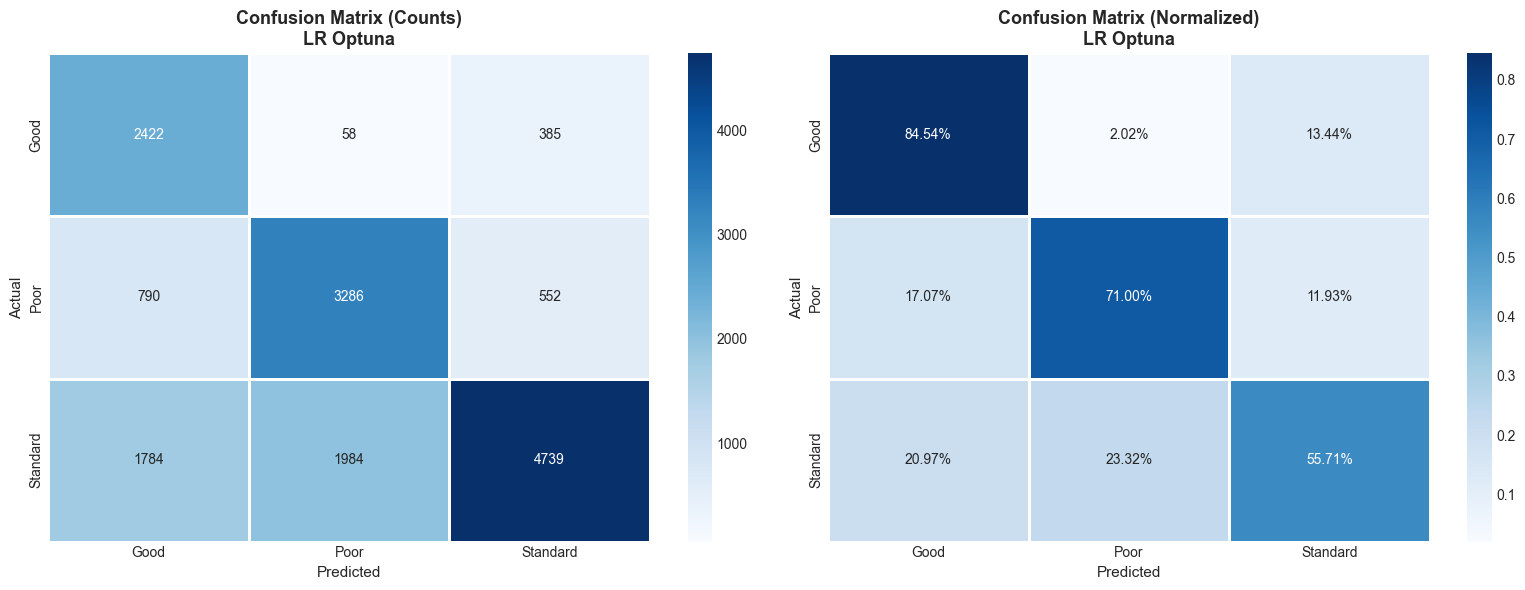

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0], linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_model_name}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

# Normalized (percentage)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1], linewidths=1, linecolor='white')
axes[1].set_title(f'Confusion Matrix (Normalized)\n{best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()


### 6.3 ROC Curve & AUC Score (One-vs-Rest)

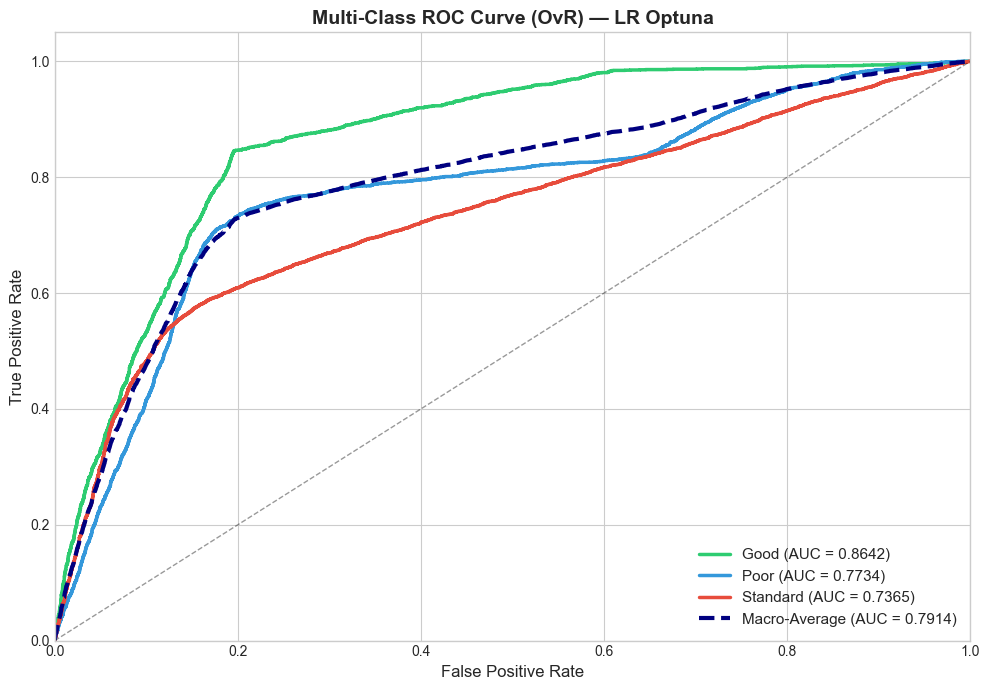

ROC AUC (weighted): 0.7701
ROC AUC (macro):    0.7914


In [ ]:
# Binarize labels for multi-class ROC
classes = np.unique(y_val)
n_classes = len(classes)
y_val_bin = label_binarize(y_val, classes=classes)

# Get probability predictions
y_prob = best_model.predict_proba(X_val_scaled)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = ['#2ecc71', '#3498db', '#e74c3c']

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}

for i in range(n_classes):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
    ax.plot(fpr_dict[i], tpr_dict[i], color=colors_roc[i], lw=2.5,
            label=f'{label_encoder.classes_[i]} (AUC = {roc_auc_dict[i]:.4f})')

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

ax.plot(all_fpr, mean_tpr, color='navy', lw=3, linestyle='--',
        label=f'Macro-Average (AUC = {roc_auc_macro:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'Multi-Class ROC Curve (OvR) — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

# Print AUC scores
print(f"ROC AUC (weighted): {roc_auc_score(y_val_bin, y_prob, average='weighted', multi_class='ovr'):.4f}")
print(f"ROC AUC (macro):    {roc_auc_score(y_val_bin, y_prob, average='macro', multi_class='ovr'):.4f}")


---

## 7. Model Interpretation (SHAP)

Using SHAP (SHapley Additive exPlanations) to understand which features are most important for credit score classification.

In [ ]:
# Sample 500 data points for SHAP (for performance)
np.random.seed(42)
sample_size = min(500, len(X_train_scaled))
sample_idx = np.random.choice(len(X_train_scaled), size=sample_size, replace=False)
X_shap_sample = X_train_scaled[sample_idx]

# Choose appropriate SHAP explainer based on model type
if isinstance(best_model, LogisticRegression):
    explainer = shap.LinearExplainer(best_model, X_shap_sample, feature_names=feature_names)
    shap_values_raw = explainer.shap_values(X_shap_sample)
else:
    # For GaussianNB, use KernelExplainer
    explainer = shap.KernelExplainer(best_model.predict_proba, X_shap_sample)
    shap_values_raw = explainer.shap_values(X_shap_sample, nsamples=100)

# Normalize to list-of-2D-arrays format (one per class)
# LinearExplainer may return 3D array (n_samples, n_features, n_classes)
# or a list of 2D arrays depending on SHAP version
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # 3D: (n_samples, n_features, n_classes) -> list of (n_samples, n_features)
    n_classes = shap_values_raw.shape[2]
    shap_values = [shap_values_raw[:, :, k] for k in range(n_classes)]
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 2:
    # Binary / single output — wrap in list
    shap_values = [shap_values_raw]
else:
    # Already a list
    shap_values = shap_values_raw

print(f'✅ SHAP values computed (sample size: {sample_size})')
print(f'   Number of classes: {len(shap_values)}')
print(f'   SHAP array shape per class: {shap_values[0].shape}')


✅ SHAP values computed (sample size: 500)
   Number of classes: 3
   SHAP array shape per class: (500, 10)


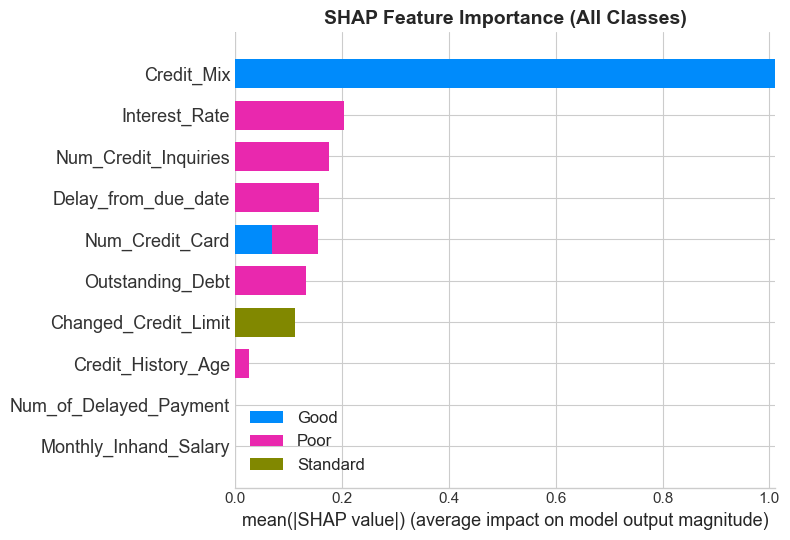

In [ ]:
# SHAP Feature Importance — Bar Plot (all classes)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names,
                  class_names=label_encoder.classes_.tolist(), plot_type='bar', show=False)
plt.title('SHAP Feature Importance (All Classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


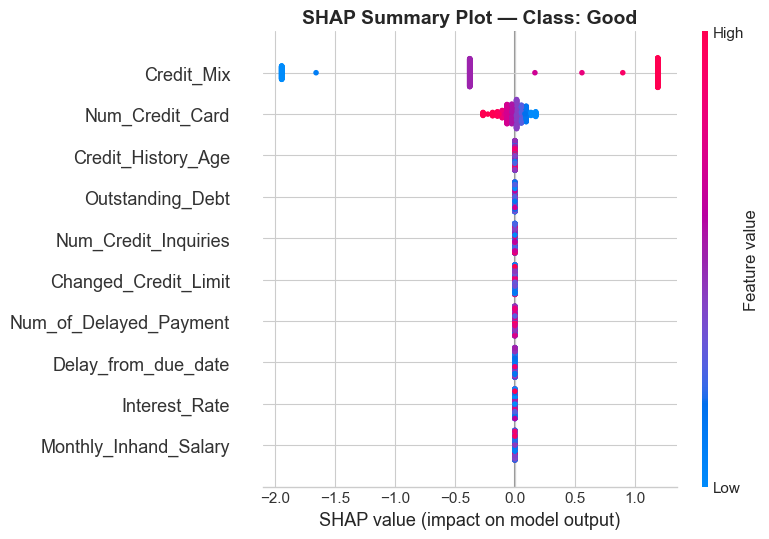

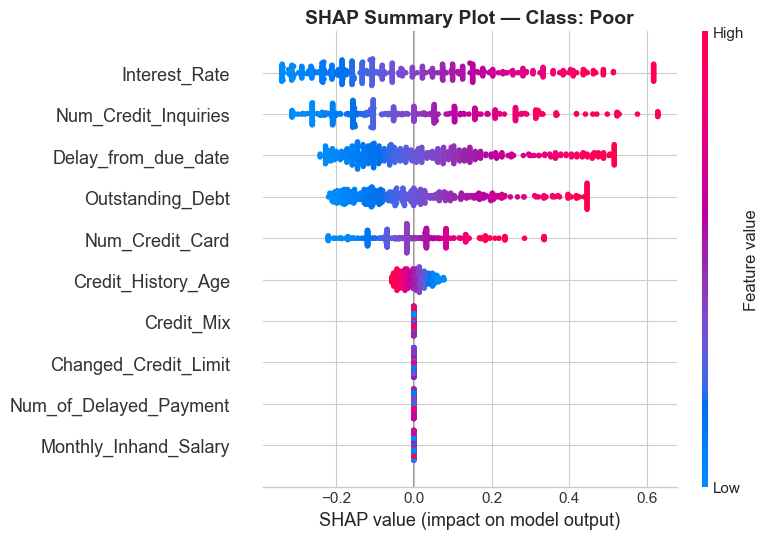

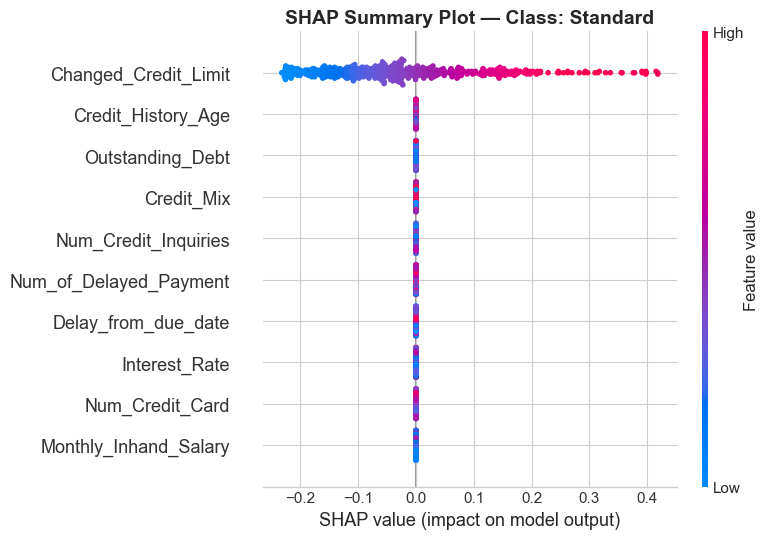

In [ ]:
# SHAP Summary Plot (beeswarm) for each class
for cls_idx, cls_name in enumerate(label_encoder.classes_):
    if cls_idx >= len(shap_values):
        break
    plt.figure(figsize=(12, 7))
    shap.summary_plot(
        shap_values[cls_idx],   # 2D array: (n_samples, n_features)
        X_shap_sample,
        feature_names=feature_names,
        show=False
    )
    plt.title(f'SHAP Summary Plot — Class: {cls_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


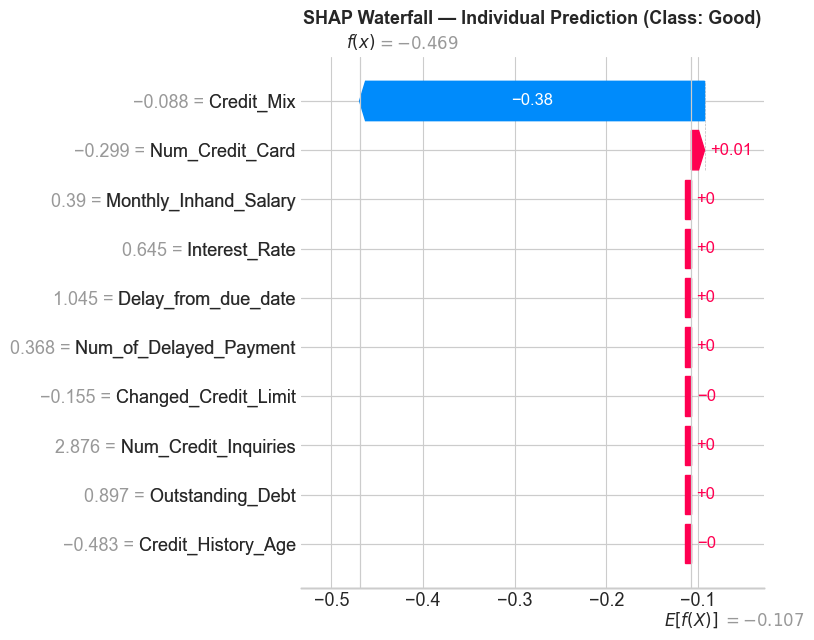

In [ ]:
# SHAP Waterfall Plot — explain a single prediction
sample_index = 0
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]   # Use class 0 base value

shap_explanation = shap.Explanation(
    values=shap_values[0][sample_index],
    base_values=base_val,
    data=X_shap_sample[sample_index],
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — Individual Prediction (Class: {label_encoder.classes_[0]})',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### SHAP Interpretation Summary

**Key insights from SHAP analysis:**

1. The **bar plot** above shows the mean absolute SHAP value for each feature across all classes. Features at the top contribute most to credit score predictions.
2. Typical top contributors include:
   - **Delay_from_due_date** and **Num_of_Delayed_Payment**: Late payment behavior strongly pushes predictions toward "Poor".
   - **Interest_Rate**: Higher interest rates are associated with lower credit scores.
   - **Outstanding_Debt**: Higher debt contributes to "Poor" classification.
   - **Annual_Income** and **Monthly_Balance**: Higher values push toward "Good" classification.
   - **Credit_History_Age**: Longer credit history correlates with better credit scores.
3. The **waterfall plot** shows how each feature contributes to a single prediction, starting from the average base expectation.

---

## 8. Prediction & Output

Apply the best model to the unseen `test.csv` and save predictions to `result.csv`.

In [ ]:
# Clean test data using training statistics
df_test_cleaned = data_cleaning(
    df_test_raw,
    is_test=True,
    global_medians=global_medians,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds
)

# Drop Credit_Score column if present (all NaN in test)
if 'Credit_Score' in df_test_cleaned.columns:
    df_test_cleaned.drop(columns=['Credit_Score'], inplace=True)

# Align test columns with training columns
missing_cols = set(original_feature_names) - set(df_test_cleaned.columns)
extra_cols = set(df_test_cleaned.columns) - set(original_feature_names)

for col in missing_cols:
    df_test_cleaned[col] = 0

# Keep only training features in the same order
df_test_cleaned = df_test_cleaned[original_feature_names]

print(f"✅ Test data cleaned and aligned.")
print(f"   Shape: {df_test_cleaned.shape}")
print(f"   Missing columns added: {missing_cols if missing_cols else 'None'}")
print(f"   Extra columns removed: {extra_cols if extra_cols else 'None'}")


✅ Test data cleaned and aligned.
   Shape: (20000, 20)
   Missing columns added: None
   Extra columns removed: None


In [ ]:
# Scale test data using the fitted scaler
X_test_scaled = scaler.transform(df_test_cleaned)
# Select features for test set
X_test_scaled = selector.transform(X_test_scaled)

# Predict credit scores
y_test_pred_encoded = best_model.predict(X_test_scaled)
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred_encoded)

print("✅ Predictions made.")
print(f"\nPredicted distribution:")
print(pd.Series(y_test_pred_labels).value_counts())


✅ Predictions made.

Predicted distribution:
Standard    7537
Poor        6792
Good        5671
Name: count, dtype: int64


In [ ]:
# Create result.csv
df_result = df_test_raw.copy()
df_result['Credit_Score'] = y_test_pred_labels

# Save to CSV (auto-detect environment)
if os.path.exists('/content'):
    result_path = '/content/DADS6003/hw4_classification/result.csv'
else:
    result_path = 'result.csv'

df_result.to_csv(result_path, index=False)

print(f'✅ result.csv saved to: {result_path}')
print(f'   Shape: {df_result.shape}')
print(f'   Credit_Score non-null: {df_result["Credit_Score"].notna().sum()} / {len(df_result)}')
print()
display(df_result[['ID', 'Customer_ID', 'Credit_Score']].head(10))


✅ result.csv saved to: result.csv
   Shape: (20000, 28)
   Credit_Score non-null: 20000 / 20000



,ID,Customer_ID,Credit_Score
0,0x2595b,CUS_0x3e03,Standard
1,0xa2e2,CUS_0x3615,Poor
2,0x131cd,CUS_0x9122,Standard
3,0x1bced,CUS_0x3371,Poor
4,0x1ee87,CUS_0xecc,Poor
5,0x9493,CUS_0x1fd1,Poor
6,0x244ce,CUS_0x55e6,Standard
7,0x1a425,CUS_0x9b38,Standard
8,0x19f08,CUS_0xbab8,Good
9,0x1c9eb,CUS_0x6525,Poor
